# Insurance Charges — Regression Pipeline

Fully self-contained notebook version of a regression pipeline, run against
`insurance.csv` with the target `charges`. No project-specific `.py` modules
required — every pipeline component (config, transformers, model zoo,
evaluator) is defined inline below.

Steps: load data → EDA → feature engineering → preprocessing pipeline
(missing-value imputation → IQR outlier capping → one-hot encoding → scaling)
→ train/val/test split → model zoo search (MLflow-logged) → pick the best
model by validation R² → evaluate once on the test set → save
`best_model.pkl`, `pipeline.pkl`, `metadata.json` under `models/`.


In [1]:
import json
import logging
import os
import time
import warnings
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    ParameterGrid,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# MLflow refuses to open a filesystem tracking store unless this is set.
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

# MLflow is chatty about pickle formats and stale experiment folders.
for _logger in ("mlflow", "mlflow.sklearn", "mlflow.utils", "root"):
    logging.getLogger(_logger).setLevel(logging.ERROR)

sns.set_theme(style="whitegrid")


## 1. Configuration

Dataset-agnostic defaults for the pipeline.

In [2]:
class Config:
    DATA_PATH = "insurance.csv"
    TARGET_COLUMN = "charges"

    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2
    CV_FOLDS = 5
    N_JOBS = -1  # Use all available cores

    # Preprocessing
    OUTLIER_FACTOR = 1.5  # IQR multiplier used by OutlierHandler

    # Hyperparameter search
    N_ITER = 20  # RandomizedSearchCV candidates per model
    SCORING = "r2"

    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"

    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)


config = Config()
DATA_PATH = config.DATA_PATH
TARGET = config.TARGET_COLUMN
RANDOM_STATE = config.RANDOM_STATE


## 2. Column heuristics

Small helpers used to prepare features.

In [3]:
def find_identifier_columns(X):
    """Non-numeric columns with a distinct value in every row.

    These are record IDs, names, free-text keys — no signal, and one-hot
    encoding them would produce a column per row.
    """
    return [
        col
        for col in X.select_dtypes(include=["object", "category"]).columns
        if X[col].nunique(dropna=False) == len(X)
    ]


def drop_columns(X, columns, reason=""):
    """Drop `columns` if present, reporting what went and why."""
    present = [col for col in dict.fromkeys(columns) if col in X.columns]
    if present:
        suffix = f" ({reason})" if reason else ""
        print(f"Dropping columns{suffix}: {sorted(present)}")
        X = X.drop(columns=present)
    return X


def describe_columns(X):
    """Return (numeric_cols, categorical_cols) discovered from dtypes."""
    numeric = X.select_dtypes(include="number").columns.tolist()
    categorical = [col for col in X.columns if col not in numeric]
    return numeric, categorical


def check_regression_target(df, target, path):
    """Validate that `target` exists and is usable as a regression target."""
    if target not in df.columns:
        raise ValueError(
            f"Target column \'{target}\' is not in {path}. "
            f"Available columns: {list(df.columns)}"
        )
    if not pd.api.types.is_numeric_dtype(df[target]):
        raise ValueError(
            f"Target column \'{target}\' is not numeric (dtype "
            f"{df[target].dtype}); this pipeline handles regression only."
        )


## 3. Load data

In [4]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()


Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()
df.describe(include="all")


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64



,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## 4. Exploratory data analysis

Encode categoricals with `pd.get_dummies` just for this correlation view (the
real encoding used for training happens later, inside the pipeline).

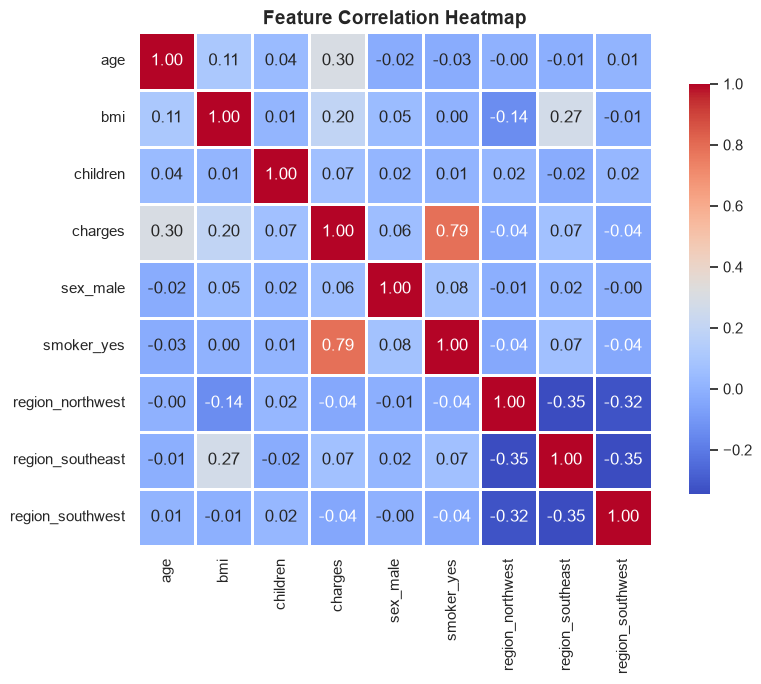


Correlation with 'charges':
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


In [7]:
encoded_for_corr = pd.get_dummies(df, drop_first=True).astype(float)
correlation_matrix = encoded_for_corr.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nCorrelation with '{TARGET}':")
print(correlation_matrix[TARGET].drop(TARGET).sort_values(ascending=False))


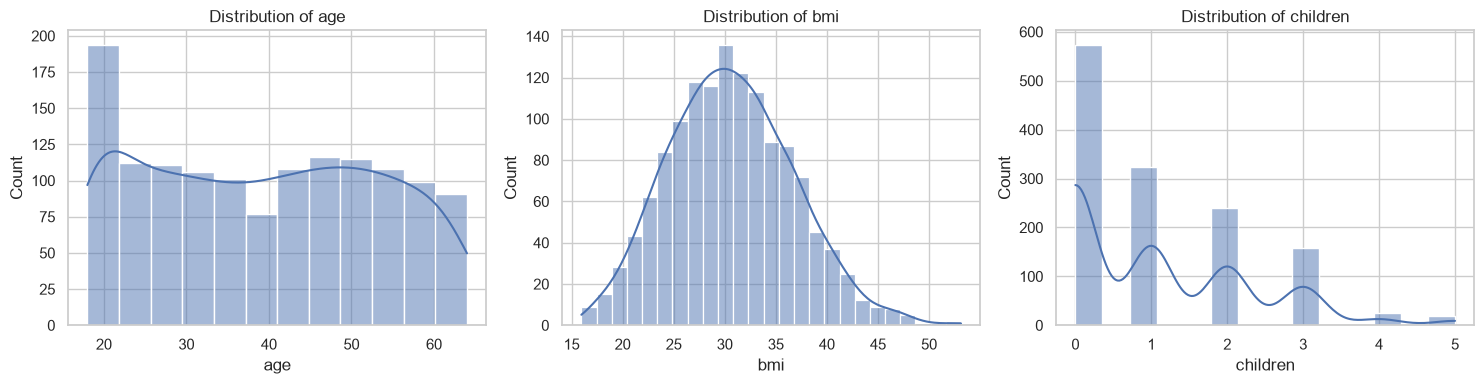

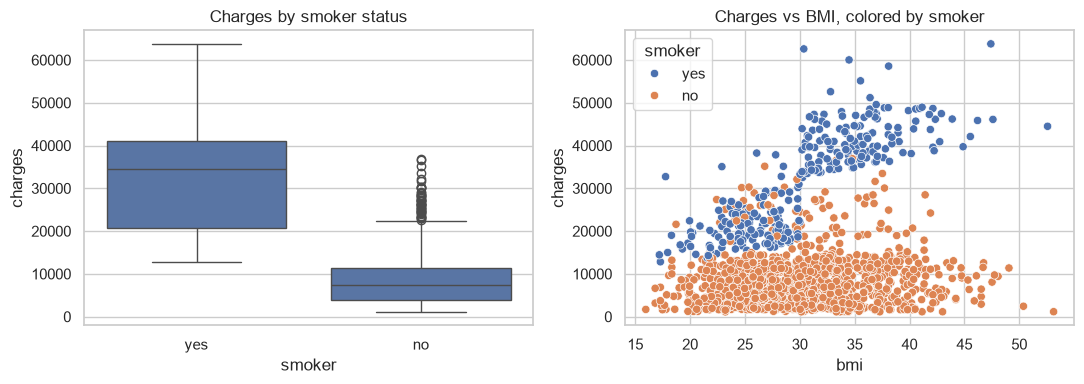

In [8]:
numeric_features = ["age", "bmi", "children"]
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 4))
for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x="smoker", y=TARGET, data=df, ax=axes[0])
axes[0].set_title("Charges by smoker status")

sns.scatterplot(x="bmi", y=TARGET, hue="smoker", data=df, ax=axes[1])
axes[1].set_title("Charges vs BMI, colored by smoker")

plt.tight_layout()
plt.show()


## 5. Feature engineering

`smoker` is encoded to 0/1 first since the interaction terms below need it
numeric. Then the requested engineered features are added:

- `age_smoker` = `age` × `smoker`
- `bmi_smoker` = `bmi` × `smoker`
- `age_bmi` = `age` × `bmi`
- `is_obese` = 1 if `bmi` >= 30 else 0

In [9]:
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})

df["age_smoker"] = df["age"] * df["smoker"]
df["bmi_smoker"] = df["bmi"] * df["smoker"]
df["age_bmi"] = df["age"] * df["bmi"]
df["is_obese"] = (df["bmi"] >= 30).astype(int)

df.head()


,age,sex,bmi,children,smoker,region,charges,age_smoker,bmi_smoker,age_bmi,is_obese
0,19,female,27.900,0,1,southwest,16884.92400,19,27.9,530.100,0
1,18,male,33.770,1,0,southeast,1725.55230,0,0.0,607.860,1
2,28,male,33.000,3,0,southeast,4449.46200,0,0.0,924.000,1
3,33,male,22.705,0,0,northwest,21984.47061,0,0.0,749.265,0
4,32,male,28.880,0,0,northwest,3866.85520,0,0.0,924.160,0


## 6. Prepare features and target

Drop rows with a missing target, split into `X`/`y`, drop identifier-like
columns (none expected here, but the check is dataset-agnostic so it stays
in).

In [10]:
check_regression_target(df, TARGET, DATA_PATH)

missing_target = df[TARGET].isna().sum()
if missing_target:
    print(f"Dropping {missing_target} rows with a missing target")
    df = df.dropna(subset=[TARGET])

y = df[TARGET]
X = df.drop(columns=[TARGET])

X = drop_columns(X, find_identifier_columns(X), "identifier-like")

numeric_cols, categorical_cols = describe_columns(X)
print(f"Rows    : {len(X)}   Features: {X.shape[1]}")
print(f"Numeric : {numeric_cols}")
print(f"Category: {categorical_cols}")


Rows    : 1338   Features: 10
Numeric : ['age', 'bmi', 'children', 'smoker', 'age_smoker', 'bmi_smoker', 'age_bmi', 'is_obese']
Category: ['sex', 'region']


In [11]:
def build_input_schema(X):
    """Describe the raw feature columns so a UI could render inputs for them."""
    schema = []
    for col in X.columns:
        if pd.api.types.is_numeric_dtype(X[col]):
            series = X[col].dropna()
            schema.append(
                {
                    "name": col,
                    "type": "numeric",
                    "min": float(series.min()) if not series.empty else 0.0,
                    "max": float(series.max()) if not series.empty else 1.0,
                    "default": float(series.median()) if not series.empty else 0.0,
                    "is_integer": bool(
                        pd.api.types.is_integer_dtype(X[col])
                        or (not series.empty and (series % 1 == 0).all())
                    ),
                }
            )
        else:
            categories = sorted(X[col].dropna().astype(str).unique().tolist())
            schema.append(
                {
                    "name": col,
                    "type": "categorical",
                    "categories": categories,
                    "default": categories[0] if categories else "",
                }
            )
    return schema


input_schema = build_input_schema(X)
input_schema


[{'name': 'age',
  'type': 'numeric',
  'min': 18.0,
  'max': 64.0,
  'default': 39.0,
  'is_integer': True},
 {'name': 'sex',
  'type': 'categorical',
  'categories': ['female', 'male'],
  'default': 'female'},
 {'name': 'bmi',
  'type': 'numeric',
  'min': 15.96,
  'max': 53.13,
  'default': 30.4,
  'is_integer': False},
 {'name': 'children',
  'type': 'numeric',
  'min': 0.0,
  'max': 5.0,
  'default': 1.0,
  'is_integer': True},
 {'name': 'smoker',
  'type': 'numeric',
  'min': 0.0,
  'max': 1.0,
  'default': 0.0,
  'is_integer': True},
 {'name': 'region',
  'type': 'categorical',
  'categories': ['northeast', 'northwest', 'southeast', 'southwest'],
  'default': 'northeast'},
 {'name': 'age_smoker',
  'type': 'numeric',
  'min': 0.0,
  'max': 64.0,
  'default': 0.0,
  'is_integer': True},
 {'name': 'bmi_smoker',
  'type': 'numeric',
  'min': 0.0,
  'max': 52.58,
  'default': 0.0,
  'is_integer': False},
 {'name': 'age_bmi',
  'type': 'numeric',
  'min': 287.28000000000003,
  'max':

## 7. Train / validation / test split

Two-step split: hold out the test set first, then carve validation out of the
remainder (64% train / 16% val / 20% test with the defaults).

In [12]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=config.VAL_SIZE, random_state=RANDOM_STATE
)

print(f"Split: train={len(X_train)} val={len(X_val)} test={len(X_test)}")


Split: train=856 val=214 test=268


## 8. Preprocessing transformers

Three custom transformers, each discovering its own columns by dtype at fit
time so the pipeline is portable across datasets:

1. `MissingValueHandler` — median for numeric columns, mode otherwise
2. `OutlierHandler` — caps numeric columns to their IQR fences. Columns with a
   zero-width IQR (rare binary flags, sparse interaction terms) are left
   uncapped — otherwise every value would collapse to a single point,
   erasing the column instead of capping outliers
3. `LocalEncoder` — one-hot encodes whatever is still categorical (`sex`,
   `region`; `smoker` is already numeric from feature engineering)

In [13]:
class MissingValueHandler(BaseEstimator, TransformerMixin):
    """Fill gaps without knowing the dataset in advance.

    Numeric columns take the training median, everything else the training
    mode. Columns that were entirely empty during fit fall back to 0 / "missing"
    so transform never emits NaN.
    """

    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        self.numeric_cols_ = df.select_dtypes(include=[np.number]).columns.tolist()
        self.fill_values_ = {}

        for col in df.columns:
            if col in self.numeric_cols_:
                value = df[col].median()
                self.fill_values_[col] = 0 if pd.isna(value) else value
            else:
                mode = df[col].mode(dropna=True)
                self.fill_values_[col] = mode.iloc[0] if not mode.empty else "missing"

        return self

    def transform(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        for col, value in self.fill_values_.items():
            if col in df.columns:
                df[col] = df[col].fillna(value)

        return df

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


class OutlierHandler(BaseEstimator, TransformerMixin):
    """Cap numeric columns to their IQR fences.

    Columns are discovered at fit time, so this works on any dataset.
    """

    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        self.numeric_cols_ = df.select_dtypes(include=[np.number]).columns.tolist()
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

        for col in self.numeric_cols_:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            if IQR == 0:
                # A zero-width IQR (rare binary flags, sparse interaction
                # terms, near-constant columns) would otherwise collapse
                # every value to Q1, erasing the column instead of capping
                # outliers.
                self.lower_bounds_[col] = -np.inf
                self.upper_bounds_[col] = np.inf
            else:
                self.lower_bounds_[col] = Q1 - (self.factor * IQR)
                self.upper_bounds_[col] = Q3 + (self.factor * IQR)

        return self

    def transform(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        for col in self.numeric_cols_:
            if col in df.columns:
                df[col] = df[col].clip(
                    lower=self.lower_bounds_[col], upper=self.upper_bounds_[col]
                )

        return df

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


class LocalEncoder(BaseEstimator, TransformerMixin):
    """One-hot encode whichever columns happen to be categorical.

    Columns are discovered at fit time from their dtype, so no dataset-specific
    column names are baked in. Unseen categories at predict time are ignored
    rather than raising.
    """

    def __init__(self):
        self.encoder = OneHotEncoder(
            drop="first", sparse_output=False, handle_unknown="ignore"
        )
        self.encoder.set_output(transform="pandas")
        self.categorical_cols_ = None
        self.numeric_cols_ = None

    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        self.categorical_cols_ = df.select_dtypes(
            include=["object", "category"]
        ).columns.tolist()
        self.numeric_cols_ = df.select_dtypes(
            exclude=["object", "category"]
        ).columns.tolist()

        if self.categorical_cols_:
            self.encoder.fit(df[self.categorical_cols_])

        return self

    def transform(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        if not self.categorical_cols_:
            return df

        encoded = self.encoder.transform(df[self.categorical_cols_])
        return df.drop(columns=self.categorical_cols_).join(encoded)

    def get_feature_names_out(self, input_features=None):
        if not self.categorical_cols_:
            return list(self.numeric_cols_)
        return list(self.numeric_cols_) + list(self.encoder.get_feature_names_out())


In [14]:
def build_pipeline(outlier_factor):
    scaler = StandardScaler().set_output(transform="pandas")
    return Pipeline(
        steps=[
            ("missing_values", MissingValueHandler()),
            ("outlier_handler", OutlierHandler(factor=outlier_factor)),
            ("local_encoder", LocalEncoder()),
            ("scaler", scaler),
        ]
    )


pipeline = build_pipeline(config.OUTLIER_FACTOR)
X_train_p = pipeline.fit_transform(X_train)
X_val_p = pipeline.transform(X_val)
X_test_p = pipeline.transform(X_test)

print(f"Encoded: {X_train_p.shape[1]} columns after preprocessing")
X_train_p.head()


Encoded: 12 columns after preprocessing


,age,bmi,children,smoker,age_smoker,bmi_smoker,age_bmi,is_obese,sex_male,region_northwest,region_southeast,region_southwest
94,1.745170,0.129173,0.719448,1.951663,3.420975,1.986318,1.516376,0.965546,-1.028442,-0.555759,-0.591741,1.684804
814,-0.235521,0.643235,0.719448,-0.512384,-0.473680,-0.499131,0.058422,0.965546,0.972345,-0.555759,1.689928,-0.593541
246,1.462214,1.239415,-0.905479,-0.512384,-0.473680,-0.499131,2.051664,0.965546,-1.028442,-0.555759,1.689928,-0.593541
794,-0.023304,0.231000,0.719448,-0.512384,-0.473680,-0.499131,0.068731,0.965546,-1.028442,1.799340,-0.591741,-0.593541
1239,-1.013650,1.907860,-0.093016,-0.512384,-0.473680,-0.499131,-0.297094,0.965546,-1.028442,-0.555759,1.689928,-0.593541


## 9. Model zoo and evaluator

`get_model_zoo` returns candidate regressors with their search spaces;
`ModelEvaluator` runs `RandomizedSearchCV` for one model, computes train/val
metrics plus cross-validation, and logs everything to MLflow.

In [15]:
def get_model_zoo(random_state=42):
    """Return {name: (estimator, param_grid)}."""
    return {
        "Linear Regression": (
            LinearRegression(),
            {"fit_intercept": [True, False]},
        ),
        "Ridge": (
            Ridge(random_state=random_state),
            {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
        ),
        "Lasso": (
            Lasso(random_state=random_state, max_iter=10000),
            {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]},
        ),
        "ElasticNet": (
            ElasticNet(random_state=random_state, max_iter=10000),
            {
                "alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
                "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
            },
        ),
        "Decision Tree": (
            DecisionTreeRegressor(random_state=random_state),
            {
                "max_depth": [3, 5, 8, 12, None],
                "min_samples_split": [2, 5, 10, 20],
                "min_samples_leaf": [1, 2, 4, 8],
            },
        ),
        "Random Forest": (
            RandomForestRegressor(random_state=random_state),
            {
                "n_estimators": [100, 200, 300, 500],
                "max_depth": [5, 10, 20, None],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": ["sqrt", "log2", 1.0],
            },
        ),
        "Gradient Boosting": (
            GradientBoostingRegressor(random_state=random_state),
            {
                "n_estimators": [100, 200, 300],
                "learning_rate": [0.01, 0.05, 0.1, 0.2],
                "max_depth": [2, 3, 5, 8],
                "subsample": [0.7, 0.85, 1.0],
            },
        ),
        "Hist Gradient Boosting": (
            HistGradientBoostingRegressor(random_state=random_state),
            {
                "learning_rate": [0.01, 0.05, 0.1, 0.2],
                "max_iter": [100, 200, 300],
                "max_leaf_nodes": [15, 31, 63],
                "min_samples_leaf": [5, 10, 20],
            },
        ),
        "SVR": (
            SVR(),
            {
                "C": [0.1, 1.0, 10.0, 100.0],
                "gamma": ["scale", "auto", 0.01, 0.1],
                "epsilon": [0.01, 0.1, 0.5],
                "kernel": ["rbf", "linear"],
            },
        ),
        "KNN": (
            KNeighborsRegressor(),
            {
                "n_neighbors": [3, 5, 7, 11, 15],
                "weights": ["uniform", "distance"],
                "p": [1, 2],
            },
        ),
        "Voting Ensemble": (
            VotingRegressor(
                estimators=[
                    ("ridge", Ridge(random_state=random_state)),
                    ("rf", RandomForestRegressor(random_state=random_state)),
                    ("gb", GradientBoostingRegressor(random_state=random_state)),
                ]
            ),
            {
                "ridge__alpha": [0.1, 1.0, 10.0],
                "rf__n_estimators": [50, 100],
                "rf__max_depth": [10, 20],
                "gb__n_estimators": [50, 100],
                "gb__learning_rate": [0.05, 0.1],
            },
        ),
    }


class ModelEvaluator:

    @staticmethod
    def train_and_evaluate(
        model,
        X_train,
        X_val,
        y_train,
        y_val,
        model_name,
        param_grids,
        cv_folds=5,
        n_jobs=-1,
        random_state=42,
        n_iter=20,
        scoring="r2",
    ):
        # Never ask for more candidates than the grid actually contains.
        if param_grids:
            n_iter = min(n_iter, len(ParameterGrid(param_grids)))
        else:
            n_iter = 1

        with mlflow.start_run(run_name=model_name):
            start_time = time.time()

            search = RandomizedSearchCV(
                model,
                param_grids,
                n_iter=n_iter,
                cv=cv_folds,
                scoring=scoring,
                n_jobs=n_jobs,
                random_state=random_state,
                verbose=0,
            )
            search.fit(X_train, y_train)

            training_time = time.time() - start_time
            best_estimator = search.best_estimator_

            y_train_pred = best_estimator.predict(X_train)
            y_val_pred = best_estimator.predict(X_val)

            train_r2 = r2_score(y_train, y_train_pred)
            val_r2 = r2_score(y_val, y_val_pred)
            metrics = {
                "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
                "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
                "train_r2": train_r2,
                "val_r2": val_r2,
                "train_mae": mean_absolute_error(y_train, y_train_pred),
                "val_mae": mean_absolute_error(y_val, y_val_pred),
                "training_time": training_time,
                "overfitting_gap": train_r2 - val_r2,
            }

            mlflow.log_params(search.best_params_)
            mlflow.log_metrics({k: v for k, v in metrics.items() if k != "training_time"})
            try:
                mlflow.sklearn.log_model(
                    sk_model=best_estimator,
                    name="model",
                    serialization_format="cloudpickle",
                )
            except Exception as exc:
                print(f"  (mlflow could not log the model artifact: {exc})")

            cv_scores = cross_val_score(
                best_estimator, X_train, y_train, cv=cv_folds, scoring=scoring, n_jobs=n_jobs
            )
            metrics["cv_r2_mean"] = cv_scores.mean()
            metrics["cv_r2_std"] = cv_scores.std()

            mlflow.log_metrics(
                {"cv_r2_mean": metrics["cv_r2_mean"], "cv_r2_std": metrics["cv_r2_std"]}
            )

            return metrics, best_estimator


## 10. Train the zoo and pick the best model

Every model is tuned with `RandomizedSearchCV`. A model that fails to fit is
skipped rather than ending the run.

In [16]:
dataset_name = os.path.splitext(os.path.basename(DATA_PATH))[0]
experiment_name = f"{dataset_name}_regression_notebook"

tracking_dir = os.path.abspath(config.EXPERIMENT_DIR)
os.makedirs(tracking_dir, exist_ok=True)

mlflow.set_tracking_uri(f"file://{tracking_dir}")

mlflow.set_experiment(experiment_name)

zoo = get_model_zoo(RANDOM_STATE)

results = {}
estimators = {}

for name, (model, param_grid) in zoo.items():
    print(f"--- {name} ---")
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            metrics, best_estimator = ModelEvaluator.train_and_evaluate(
                model=model,
                X_train=X_train_p,
                X_val=X_val_p,
                y_train=y_train,
                y_val=y_val,
                model_name=name,
                param_grids=param_grid,
                cv_folds=config.CV_FOLDS,
                n_jobs=config.N_JOBS,
                random_state=RANDOM_STATE,
                n_iter=config.N_ITER,
                scoring=config.SCORING,
            )
    except Exception as exc:  # a bad fit on one model shouldn't end the run
        print(f"  skipped: {exc}\n")
        continue

    results[name] = metrics
    estimators[name] = best_estimator
    print(
        f"  val R2={metrics['val_r2']:.4f}  "
        f"cv R2={metrics['cv_r2_mean']:.4f}  "
        f"MAE={metrics['val_mae']:.4f}\n"
    )

if not results:
    raise RuntimeError("Every model failed to train; nothing to save.")

pd.DataFrame(
    {name: {"val_r2": m["val_r2"], "cv_r2_mean": m["cv_r2_mean"], "val_mae": m["val_mae"]}
     for name, m in results.items()}
).T.sort_values("val_r2", ascending=False)


--- Linear Regression ---


  val R2=0.8183  cv R2=0.8406  MAE=3120.8569

--- Ridge ---
  val R2=0.8182  cv R2=0.8406  MAE=3121.5682

--- Lasso ---


  val R2=0.8183  cv R2=0.8406  MAE=3120.3956

--- ElasticNet ---


  val R2=0.8181  cv R2=0.8406  MAE=3122.6707

--- Decision Tree ---


  val R2=0.8178  cv R2=0.8536  MAE=3050.3533

--- Random Forest ---


...

  val R2=0.8231  cv R2=0.8571  MAE=2951.1277

--- SVR ---


  val R2=0.7693  cv R2=0.7592  MAE=3067.9185

--- KNN ---


  val R2=0.8004  cv R2=0.8482  MAE=3115.5246

--- Voting Ensemble ---


  val R2=0.8267  cv R2=0.8607  MAE=2827.0626



,val_r2,cv_r2_mean,val_mae
Voting Ensemble,0.826732,0.860720,2827.062639
Random Forest,0.826233,0.862710,2852.168833
Gradient Boosting,0.824090,0.860192,2896.910411
Hist Gradient Boosting,0.823140,0.857111,2951.127717
Linear Regression,0.818307,0.840561,3120.856898
Lasso,0.818269,0.840571,3120.395570
Ridge,0.818239,0.840567,3121.568235
ElasticNet,0.818128,0.840567,3122.670670
Decision Tree,0.817822,0.853596,3050.353251
KNN,0.800419,0.848218,3115.524629


## 10b. Compare models on validation metrics

Three horizontal bar charts, one per metric, each sorted best-to-worst
top-to-bottom with the winning model highlighted:

- **Validation R²** — higher is better
- **Validation RMSE** — lower is better
- **Overfitting gap** (train R² − val R²) — closer to 0 is better

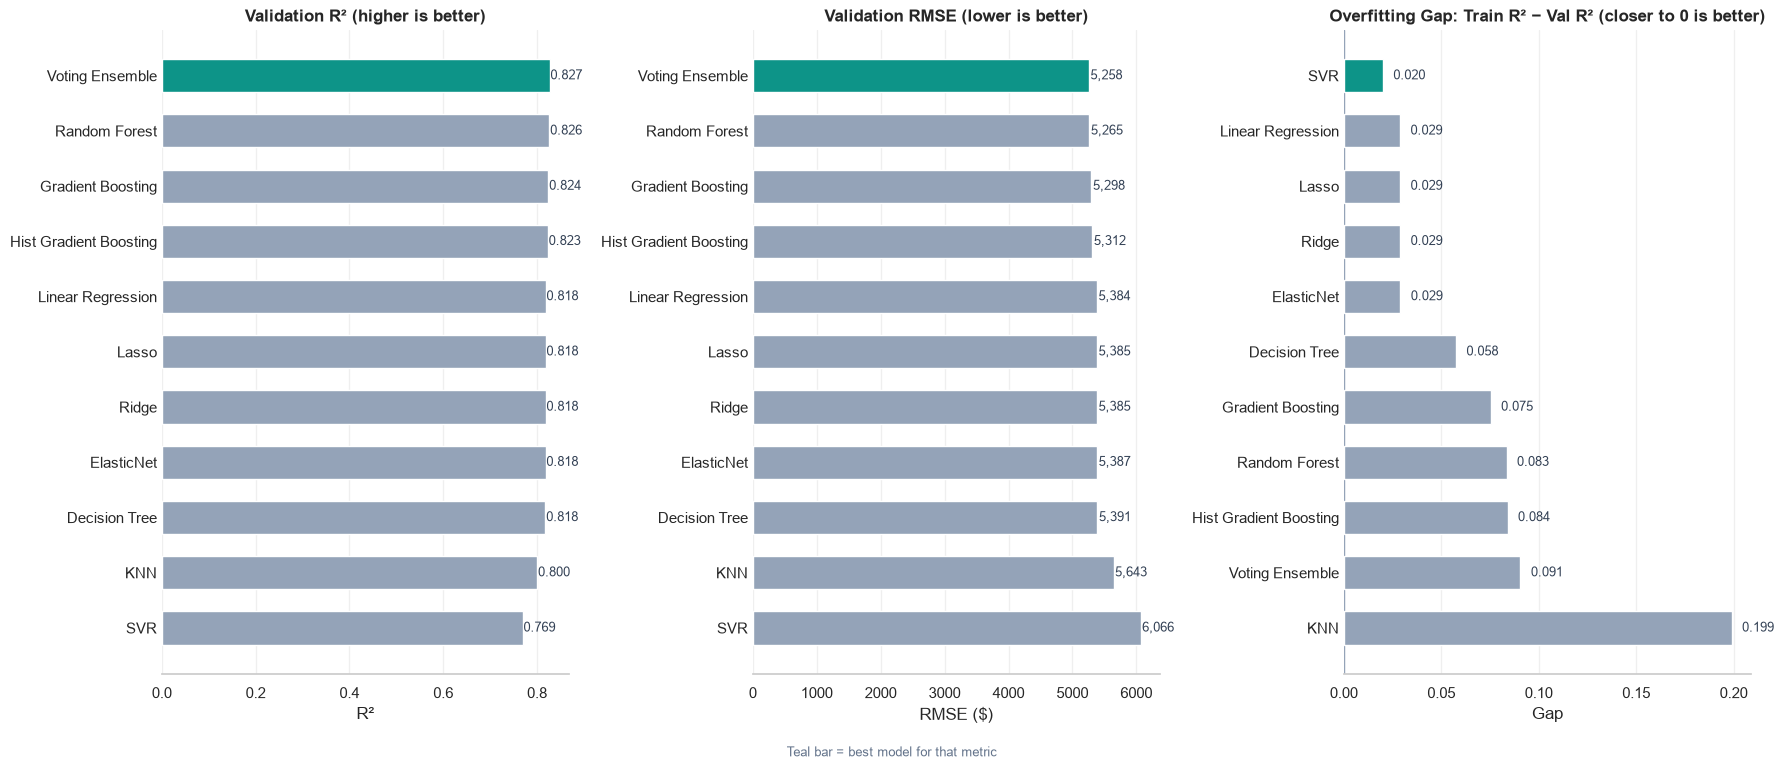

In [17]:
metrics_df = pd.DataFrame(
    {
        name: {
            "val_r2": m["val_r2"],
            "val_rmse": m["val_rmse"],
            "overfitting_gap": m["overfitting_gap"],
        }
        for name, m in results.items()
    }
).T

BAR_COLOR = "#94a3b8"   # slate — every model
BEST_COLOR = "#0d9488"  # teal — best model for this metric


def plot_metric_bars(ax, series, title, xlabel, better="high", fmt="{:.3f}"):
    """Horizontal bar chart of one metric across models, best model on top."""
    if better == "high":
        order = series.sort_values(ascending=True)
        best_name = series.idxmax()
    elif better == "low":
        order = series.sort_values(ascending=False)
        best_name = series.idxmin()
    else:  # "zero" — closer to 0 is better
        order = series.reindex(series.abs().sort_values(ascending=False).index)
        best_name = series.abs().idxmin()

    colors = [BEST_COLOR if name == best_name else BAR_COLOR for name in order.index]
    bars = ax.barh(order.index, order.values, color=colors, height=0.6, zorder=3)

    span = order.values.max() - order.values.min()
    pad = span * 0.03 if span else 0.01
    for bar, value in zip(bars, order.values):
        x = bar.get_width()
        ax.text(
            x + pad if x >= 0 else x - pad,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(value),
            va="center",
            ha="left" if x >= 0 else "right",
            fontsize=9,
            color="#334155",
        )

    if better == "zero":
        ax.axvline(0, color="#94a3b8", linewidth=1, zorder=2)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.3, zorder=0)
    ax.grid(axis="y", visible=False)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)


fig, axes = plt.subplots(1, 3, figsize=(18, 0.5 * len(metrics_df) + 2))

plot_metric_bars(
    axes[0], metrics_df["val_r2"],
    "Validation R² (higher is better)", "R²", better="high",
)
plot_metric_bars(
    axes[1], metrics_df["val_rmse"],
    "Validation RMSE (lower is better)", "RMSE ($)", better="low", fmt="{:,.0f}",
)
plot_metric_bars(
    axes[2], metrics_df["overfitting_gap"],
    "Overfitting Gap: Train R² − Val R² (closer to 0 is better)", "Gap", better="zero",
)

fig.text(0.5, -0.02, "Teal bar = best model for that metric", ha="center", fontsize=9, color="#64748b")
plt.tight_layout()
plt.show()


## 11. Evaluate the best model on the held-out test set

In [18]:
def evaluate(model, X, y):
    predictions = model.predict(X)
    return {
        "r2": float(r2_score(y, predictions)),
        "mae": float(mean_absolute_error(y, predictions)),
        "rmse": float(np.sqrt(mean_squared_error(y, predictions))),
    }


best_name = max(results, key=lambda name: results[name]["val_r2"])
best_model = estimators[best_name]
test_metrics = evaluate(best_model, X_test_p, y_test)

print(f"Best model: {best_name}")
print(f"  val  R2  : {results[best_name]['val_r2']:.4f}")
print(f"  test R2  : {test_metrics['r2']:.4f}")
print(f"  test MAE : {test_metrics['mae']:.4f}")
print(f"  test RMSE: {test_metrics['rmse']:.4f}")


Best model: Voting Ensemble
  val  R2  : 0.8267
  test R2  : 0.8813
  test MAE : 2335.2577
  test RMSE: 4292.9698


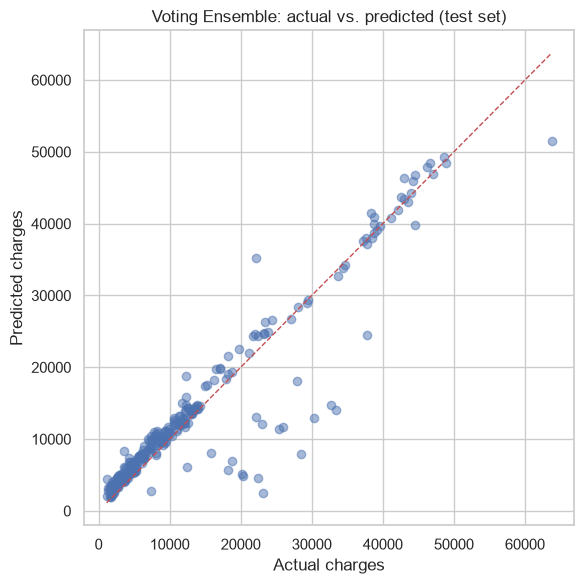

In [19]:
y_test_pred = best_model.predict(X_test_p)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title(f"{best_name}: actual vs. predicted (test set)")
plt.tight_layout()
plt.show()


## 12. Save the trained pipeline and model

Writes `models/<dataset>_<timestamp>/` with `best_model.pkl`, `pipeline.pkl`,
and `metadata.json`.

In [20]:
version_dir = os.path.join(
    config.MODEL_DIR,
    f"{dataset_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
)
os.makedirs(version_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(version_dir, "best_model.pkl"))
joblib.dump(pipeline, os.path.join(version_dir, "pipeline.pkl"))

metadata = {
    "dataset": DATA_PATH,
    "dataset_name": dataset_name,
    "target": TARGET,
    "model_name": best_name,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "n_rows": int(len(X)),
    "feature_names": list(X.columns),
    "input_schema": input_schema,
    "val_metrics": {
        "r2": results[best_name]["val_r2"],
        "mae": results[best_name]["val_mae"],
        "rmse": results[best_name]["val_rmse"],
    },
    "test_metrics": test_metrics,
    "all_models": {
        name: {"val_r2": m["val_r2"], "cv_r2_mean": m["cv_r2_mean"]}
        for name, m in results.items()
    },
}
with open(os.path.join(version_dir, "metadata.json"), "w") as handle:
    json.dump(metadata, handle, indent=2)

print(f"Saved to {version_dir}/")


Saved to models/insurance_20260901_144401/


## 13. Model card

A short, human-readable summary of the deployed model — what it is, what
it's for, what it was trained/evaluated on, and where it might fall short.
Saved as `model_card.json` alongside the pickled artifacts.

In [21]:
model_card = {
    "model_details": {
        "name": best_name,
        "version": os.path.basename(version_dir),
        "type": type(best_model).__name__,
        "framework": f"scikit-learn=={__import__('sklearn').__version__}",
        "trained_at": metadata["trained_at"],
        "trained_by": "insurance_regression_pipeline.ipynb (automated model-zoo search)",
    },
    "intended_use": {
        "primary_use": (
            "Estimate annual medical insurance charges for a US policyholder "
            "from demographic and lifestyle attributes — premium estimation, "
            "risk scoring, and identifying which factors drive cost."
        ),
        "primary_users": "Analysts prototyping insurance pricing models.",
        "out_of_scope": [
            "Automated, human-reviewed individual coverage or claim decisions.",
            "Populations outside the training distribution (non-US policyholders, "
            "ages under 18 or over 64).",
        ],
    },
    "training_data": {
        "dataset": DATA_PATH,
        "rows": int(len(X)),
        "target": TARGET,
        "raw_features": ["age", "sex", "bmi", "children", "smoker", "region"],
        "engineered_features": ["age_smoker", "bmi_smoker", "age_bmi", "is_obese"],
        "split": {"train": len(X_train), "val": len(X_val), "test": len(X_test)},
    },
    "preprocessing": [
        "Median (numeric) / mode (categorical) imputation of missing values",
        f"IQR outlier capping (factor={config.OUTLIER_FACTOR})",
        "One-hot encoding of sex/region (drop first)",
        "StandardScaler",
    ],
    "metrics": {
        "validation": results[best_name],
        "test": test_metrics,
    },
    "model_comparison": metadata["all_models"],
    "limitations_and_caveats": [
        "Trained on a single, small (1,338-row) public dataset; not validated "
        "against a real claims population.",
        f"Overfitting gap (train R² − val R²) of "
        f"{results[best_name]['overfitting_gap']:.3f} for the selected model.",
        "No fairness/bias audit has been performed across sex or region.",
    ],
    "ethical_considerations": [
        "`sex` and `region` are used as predictors; review for disparate impact "
        "before any pricing use.",
        "Predictions should not be the sole basis for coverage or pricing decisions.",
    ],
}

with open(os.path.join(version_dir, "model_card.json"), "w") as handle:
    json.dump(model_card, handle, indent=2)

print(f"Saved model card to {version_dir}/model_card.json")


Saved model card to models/insurance_20260901_144401/model_card.json
